# BoW기반 텍스트 분석 연습

1. 적절한 데이터셋을 찾거나 생성하고, 적절한 전처리를 진행한다.
2. TF-IDF Vectorizer를 이용하여 벡터화한다.
3. Cosine Similarity를 계산하여 입력된 문자열의 긍/부정을 판단한다. (중심점으로 비교 kmeans, tf)

In [5]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

treasure_df= pd.read_csv('../../data/heritage_token.csv')
treasure_text_df= pd.read_csv('../../data/heritage_sent.csv')
words = treasure_df['word'].astype(str).unique().tolist()
texts = treasure_text_df['sentence'].astype(str).tolist()
count_vectorizer = CountVectorizer(vocabulary=words)

text_vecs = count_vectorizer.transform(texts)
print(type(text_vecs))
print(text_vecs.toarray())

<class 'scipy.sparse._csr.csr_matrix'>
[[1 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [6]:
print(count_vectorizer.get_feature_names_out())
print(count_vectorizer.vocabulary_)

['충청남도' '청양군' '칠갑산' ... '계부' '개폐' '영법']
{'충청남도': 0, '청양군': 1, '칠갑산': 2, '자리': 3, '잡다': 4, '장곡사': 5, '상': 6, '대웅전': 7, '안': 8, '모시다': 9, '철불': 10, '좌상': 11, '나무': 12, '되다': 13, '배경': 14, '거대하다': 15, '사각형': 16, '돌': 17, '만들다': 18, '위': 19, '높직하다': 20, '앉다': 21, '머리': 22, '에는': 23, '상투': 24, '모양': 25, '아담하다': 26, '표현': 27, '되어다': 28, '얼굴': 29, '은': 30, '둥글다': 31, '단아': 32, '한': 33, '모습': 34, '이다': 35, '신체': 36, '는': 37, '건장하다': 38, '당당하다': 39, '편이': 40, '양감': 41, '풍부하다': 42, '않다': 43, '탄력': 44, '적': 45, '인': 46, '부피': 47, '감다': 48, '줄다': 49, '들다': 50, '세기': 51, '후반': 52, '만들어지다': 53, '불': 54, '상임': 55, '알': 56, '수': 57, '오른손': 58, '손끝': 59, '땅': 60, '향': 61, '하다': 62, '무릎': 63, '놓이다': 64, '왼손': 65, '약': 66, '항아리': 67, '얹히다': 68, '지금': 69, '없다': 70, '오른쪽': 71, '어깨': 72, '드러내다': 73, '왼쪽': 74, '만을': 75, '감싸다': 76, '옷': 77, '느슨하다': 78, '처리': 79, '주름': 80, '드문드문': 81, '각형': 82, '대좌': 83, '불상': 84, '보다': 85, '장엄하다': 86, '보여주다': 87, '중': 88, '단': 89, '형태': 90, '대가': 91, '넓다': 92, '높다': 93, '반면':

In [7]:
vocab = sorted(count_vectorizer.vocabulary_.items(), key=lambda x: x[1])
vocab_df = pd.DataFrame(vocab, columns=['word', 'idx'])
vocab_df

,word,idx
0,충청남도,0
1,청양군,1
2,칠갑산,2
3,자리,3
4,잡다,4
...,...,...
13999,규제,13999
14000,툇간,14000
14001,계부,14001
14002,개폐,14002


In [8]:
word_counts = text_vecs.toarray().sum(axis=0)
vocab_df['count'] = vocab_df['idx'].apply(lambda i: word_counts[i])

vocab_df = vocab_df.drop(columns=['idx'])
vocab_df
vocab_df = vocab_df.sort_values(by='count', ascending=False).head(3058)

### TfidfVectorizer

In [18]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
treasure_df= pd.read_csv('../../data/heritage_token.csv')
treasure_text_df= pd.read_csv('../../data/heritage_sent.csv')
words = treasure_df['word'].astype(str).unique().tolist()
texts = treasure_text_df['sentence'].astype(str).tolist()

stopwords = ['이다', '있다', '없다', '하다', '그리고', '하며', '으로', '에서', '에게',
            '한', '것', '들', '및', '또한', '같다', '매우', '않다', '위해', '원래', 
            '현재', '때의', '위층', '면의', '가로', '세로', '이', '가', '은', '는', '을', '를', '의']
tfidf_vectorizer = TfidfVectorizer(
    vocabulary=vocab_df['word'],
    stop_words=stopwords,
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=0.05,
    max_features=2000
)

text_vecs = tfidf_vectorizer.fit_transform(texts)
arr = text_vecs.toarray()
column = tfidf_vectorizer.get_feature_names_out()

['조선', '고려', '가운데', '하고', '그린', '남아', '당시', '높이', '가장', '다시', '여러', '보아', '기둥', '특히', '조선시대', '크게', '위로', '통해', '통일신라', '고려시대', '신라', '세운', '이라고', '많이', '기단', '지름', '세조', '지은', '대한', '우리나라', '임진왜란', '이후', '이를', '아가리', '선조', '역시', '지붕', '앞면', '후기', '세종', '화엄경', '중국', '길이', '서로', '왼쪽', '불상', '처음', '오른쪽', '아래', '옆면']
상위 900개 feature가 top_900_features.csv로 저장되었습니다.


In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer

# 벡터의 길이를 1로 맞춰서 방향성만 보게 합니다. (텍스트 군집화 필수 코스)
normalizer = Normalizer()
text_vecs_norm = normalizer.fit_transform(text_vecs)

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(text_vecs_norm)
document_df = pd.DataFrame({'sentence': texts, 'cluster': clusters})
feature_names = tfidf_vectorizer.get_feature_names_out()
document_df

,sentence,cluster
0,"충청남도 청양군 칠갑산에 자리잡은 장곡사 상대웅전 안에 모셔져 있는 철불좌상으로, ...",2
1,"머리 위에는 상투 모양의 머리가 아담하게 표현되어 있고, 얼굴은 둥글고 단아한 모습이다.",2
2,신체는 건장하고 당당한 편이지만 양감이 풍부하지 않고 탄력적인 부피감도 줄어 들어 ...,2
3,"오른손은 손끝이 땅을 향하도록 하고 있으며, 무릎 위에 놓인 왼손에는 약항아리가 얹...",3
4,"오른쪽 어깨를 드러내고 왼쪽 어깨만을 감싼 옷은 느슨하게 처리되었고, 옷주름 또한 ...",2
...,...,...
17154,그리고 안채에서 뻗어 나온 온돌방 ２칸은 이 마루 뒤로해서 사랑방에 1칸이 연결되어...,2
17155,안방의 서쪽과 뒤편으로는 사랑채까지 쪽마루가 연결되어 있어 사랑채에서 안채로 갈 수...,2
17156,평면구성에 있어서는 왼쪽 끝에 누 １칸이 있으며 전면에 반 칸의 툇마루가 대청에 나...,2
17157,또한 궁전의 조영법식과 기술력으로 건축되어 세련되면서 단아한 세부양식이 궁궐건축 고...,2


In [30]:
hotel_idx = document_df[document_df['cluster'] == 2].index
base_idx = 1
document_df.iloc[base_idx]

sentence    머리 위에는 상투 모양의 머리가 아담하게 표현되어 있고, 얼굴은 둥글고 단아한 모습이다.
cluster                                                     2
Name: 1, dtype: object

### Cosine Similarity

In [31]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

doc_arr = text_vecs.toarray()
pos_sim = cosine_similarity(doc_arr[11352:11353], doc_arr)


In [32]:
opinions_sim = cosine_similarity(text_vecs[base_idx], text_vecs)
opinions_sim

array([[0., 1., 0., ..., 0., 0., 0.]], shape=(1, 17159))

### 2 기준으로 긍 부정 판별

In [33]:
opinions_sorted_idx = opinions_sim.argsort()[:, ::-1]
opinions_sorted_idx = opinions_sorted_idx[:, 1:]
opinions_sorted_idx = opinions_sorted_idx.reshape(-1)

result_df = document_df.iloc[opinions_sorted_idx][['sentence', 'cluster']]
opinions_sim = opinions_sim.reshape(-1)
result_df['similarity'] = opinions_sim[opinions_sorted_idx]
result_df['result'] = np.where(result_df['similarity'] > 0.5, '긍', '부')
result_df

,sentence,cluster,similarity,result
7193,머리 위에는 상투 모양의 머리가 매우 작아서 우뚝해 보이며 사각형의 얼굴은 후덕한 ...,2,1.0,긍
808,"머리 위에는 크고 높은 상투 모양의 머리가 있고, 신체에 비하여 비교적 큰 얼굴은 ...",2,1.0,긍
4748,"머리 위에는 상투 모양의 머리가 작게 표현되어 있고, 풍만한 둥근 얼굴에서는 강한 ...",2,1.0,긍
5785,"머리 위에는 상투 모양의 보계가 솟아 있으며, 보관은 없어진 상태이다.",2,1.0,긍
11930,머리 위에는 넓직한 상투 모양의 머리가 있으며 얼굴은 둥글고 단정한 인상이다.,2,1.0,긍
...,...,...,...,...
17140,주합루와 영화당 구역을 감싸고 있는 작은 능선을 지나면 골짜기에 연경당이 자리 잡고...,2,0.0,부
17139,"이처럼 주합루는 역사적, 건축사적 가치가 높다.",2,0.0,부
17138,2층 열람실은 사방의 빼어난 경관을 조망할 수 있도록 배치하는 등 건물의 기능에 맞...,2,0.0,부
17137,"또한 건물은 경사진 높은 지형에 배치하여 자연과 조화를 이루도록 하였으며, 1층은 ...",2,0.0,부


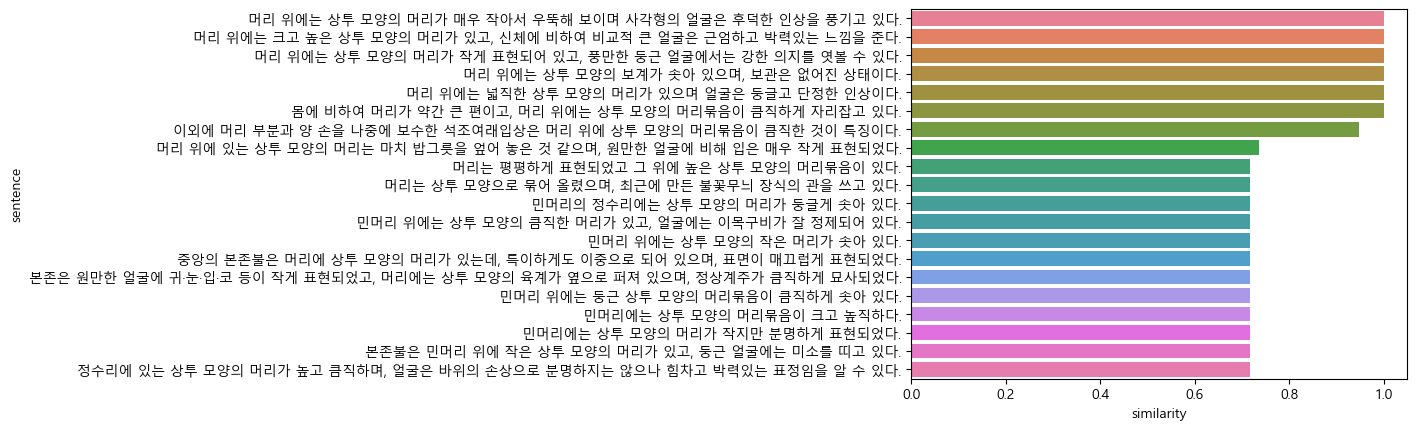

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  

sns.barplot(x='similarity', y='sentence', data=result_df.iloc[:20], hue='sentence')
plt.show()